# Ideal and error Types Sim
This notebook is meant to simulate the ideal oracle as well as all the 'basic' error types (all error types that result from the ideal Hamiltonian's terms, no discretization or scheduling errors and so on)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from htdse import *
from htdse.submodules.spin import *

from simutils import *

plt.rcParams['figure.figsize'] = (10, 6)

## Ramping Schedule

In [2]:
def tanh_schedule(c, T):
    # Returns A(t) and B(t) given C and T
    # if t > T, A(t) = 1 and B(t) = 0
    A = lambda t: np.where(
        np.asarray(t) < T,
        0.5 * (1 + np.tanh(c * (2 * np.asarray(t) / T - 1))),
        1.0
    )
    return A, (lambda t: 1 - A(t))

For 4 ions, the Hamiltonian with two ancillas and two registers (in system basis) looks like:
$$
H(s) =
    A(s)\left[ 
      s_1 \sigma_x^{r1} \sigma_x^{a1}  
      + s_1 \sigma_x^{r1} \sigma_x^{a2}  
      + s_2 \sigma_x^{r2} \sigma_x^{a1}
      + s_2 \sigma_x^{r2} \sigma_x^{a2}
      - E(\sigma_x^{a1} + \sigma_x^{a2})
    \right] \\
    + B(s)(\sigma_z^{a1} + \sigma_z^{a2})
$$
I will assign the qubits in the order: r1, r2, a1, a2

In [3]:
# Define state space:
subsystems = {"r1": 2, "r2": 2, "a1": 2, "a2": 2}
# A(s) Terms:
Xr1Xa1 = pauli_term("Xr1 Xa1")
Xr1Xa2 = pauli_term("Xr1 Xa2")
Xr2Xa1 = pauli_term("Xr2 Xa1")
Xr2Xa2 = pauli_term("Xr2 Xa2")
Xa1 = pauli_term("Xa1")
Xa2 = pauli_term("Xa2")

# B(s) Terms:
Za1 = pauli_term("Za1")
Za2 = pauli_term("Za2")

# Error terms:
Xa1Xa2 = pauli_term("Xa1 Xa2")
Xr1Xr2 = pauli_term("Xr1 Xr2")

In [4]:
def oracle_ideal(A_t, B_t, s1=1, s2=1, sz=1, E=0):
    # Given functions of time, A_t, B_t and threshold energy E, generate errorless Hamiltonian
    H = System(subsystems)
    return H + A_t * (s1*(Xr1Xa1 + Xr1Xa2) + s2*(Xr2Xa1 + Xr2Xa2) - (E * (Xa1 + Xa2))) + B_t * (sz*(Za1 + Za2))

In [5]:
# Define errorless hamiltonian, give terms names (?) or just allow adding of asymmetries
# print(Xa1 + 1.05*Xa2 == Xa1 + Xa2 + 0.05 * Xa2)
T = 1000.0
c = 10.0
s1 = 1.0
s2 = 2.0
post_time = 0.2 * T
A, B = tanh_schedule(c, T)
H0 = oracle_ideal(A, B, s1=s1, s2=s2)
assert tuple(H0.subsystems) == ("r1", "r2", "a1", "a2")

times = np.linspace(0, T, 200)
I_reg = np.eye(4, dtype=complex)
P00 = projector(ket("00")); P01 = projector(ket("01"))
P10 = projector(ket("10")); P11 = projector(ket("11"))
T_plus = ket("00")
T_zero = (ket("01") + ket("10")) / np.sqrt(2)
T_minus = ket("11")
S = (ket("01") - ket("10")) / np.sqrt(2)
P_same = otimes(I_reg, P00 + P11)
P_different = otimes(I_reg, P01 + P10)
P_T_plus = otimes(I_reg, projector(T_plus))
P_T_zero = otimes(I_reg, projector(T_zero))
P_T_minus = otimes(I_reg, projector(T_minus))
P_singlet = otimes(I_reg, projector(S))
P_triplet = P_T_plus + P_T_zero + P_T_minus
register_x_states = [otimes(hadamard[:, i], hadamard[:, j])
                     for i, j in ((0, 0), (0, 1), (1, 0), (1, 1))]
triplet_basis = np.column_stack([T_plus, T_zero, T_minus])


initial_state = otimes(ket("00"), ket("01"))
initial_state_gate = otimes(ket("00"), T_zero)

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1200, method

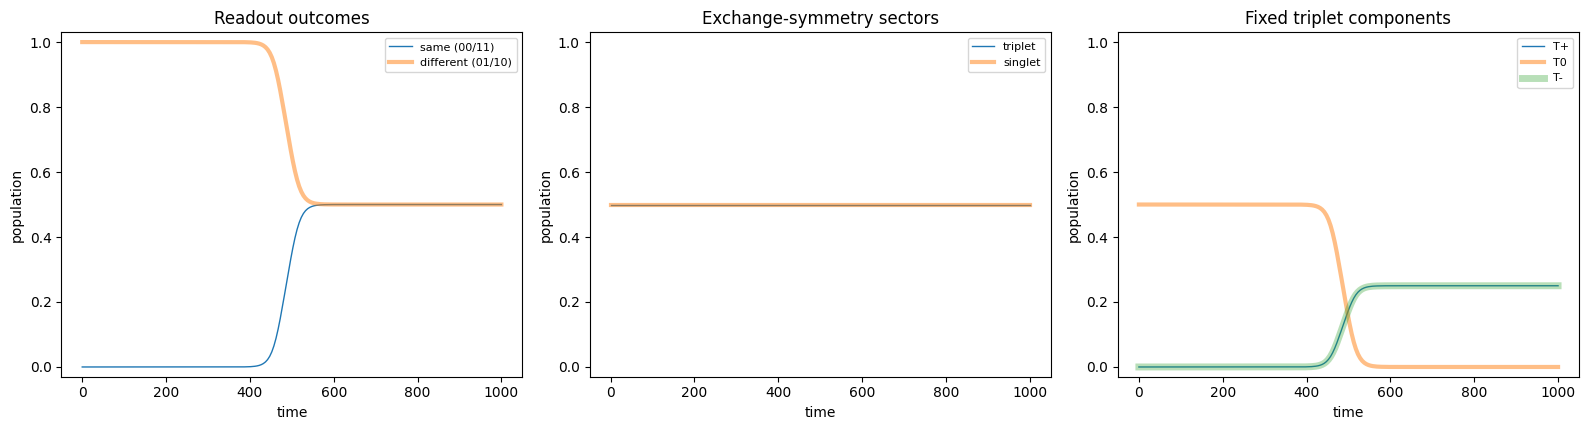

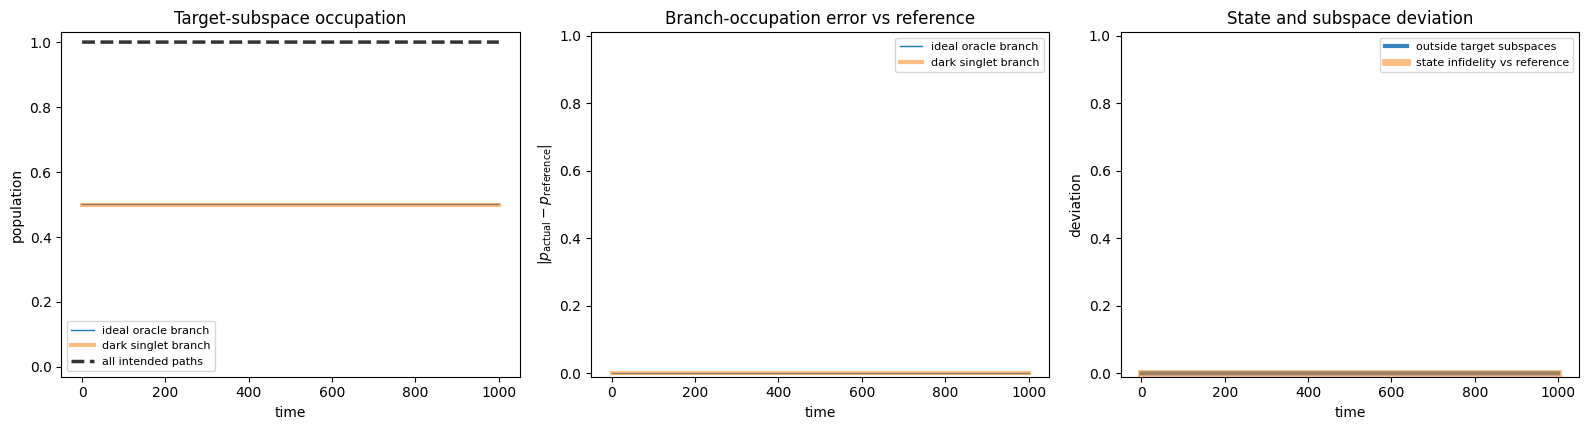

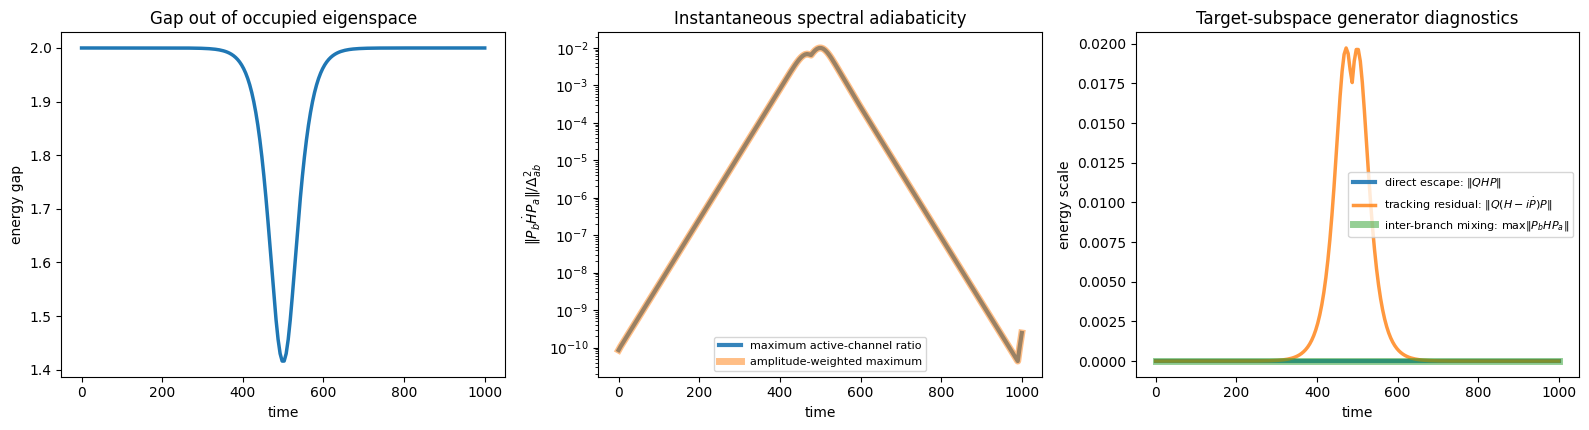

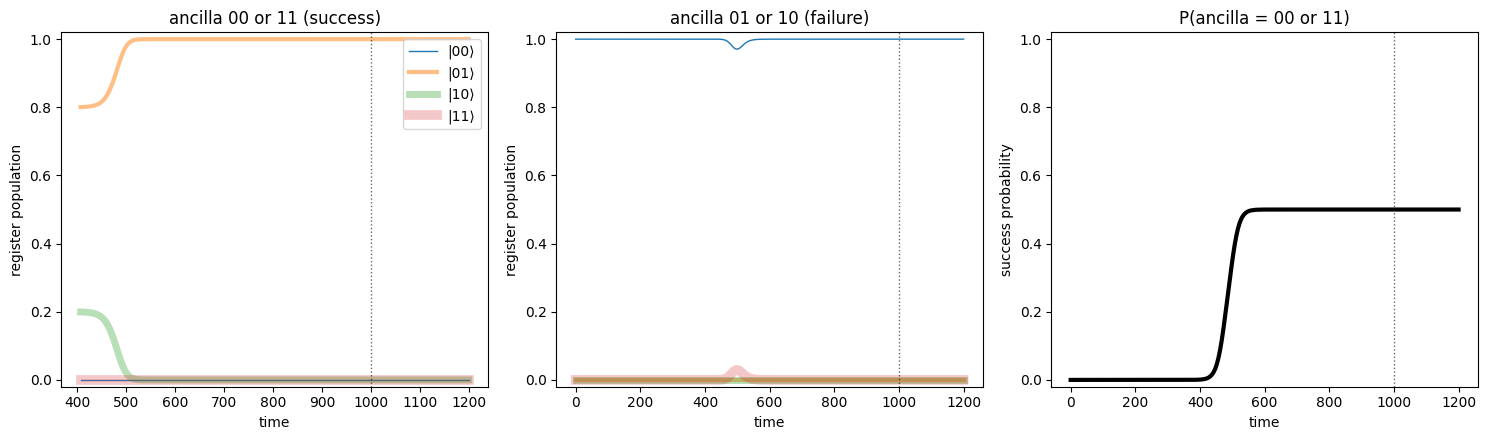

In [6]:

def transported_success_projector(t):
    result = np.zeros((16, 16), dtype=complex)
    for register_state in register_x_states:
        sector_basis = np.column_stack([otimes(register_state, np.eye(4)[:, j]) for j in range(4)])
        block = sector_basis.conj().T @ H0.H(t) @ sector_basis
        energies, vectors = np.linalg.eigh(triplet_basis.conj().T @ block @ triplet_basis)
        target = triplet_basis @ vectors[:, np.argmin(np.abs(energies))]
        result += projector(otimes(register_state, target))
    return result
diagnostics = {
    "T+": P_T_plus, "T0": P_T_zero, "T-": P_T_minus,
    "singlet": P_singlet, "triplet": P_triplet,
    "same (00/11)": P_same, "different (01/10)": P_different,
}
diagnostic_groups = {
    "Readout outcomes": ["same (00/11)", "different (01/10)"],
    "Exchange-symmetry sectors": ["triplet", "singlet"],
    "Fixed triplet components": ["T+", "T0", "T-"],
}
figures, oracle_metrics = plot_oracle_suite(
    H0, initial_state, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector,
                       "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups,
    post_time=post_time,
)



## Asymmetric \(I_x\) coupling to the ancillas - differential mode

The ideal ancilla coupling is
$$
H_{XX}^{\mathrm{ideal}}(t)=A(t)\left[s_1X_{r_1}(X_{a_1}+X_{a_2})+s_2X_{r_2}(X_{a_1}+X_{a_2})\right].
$$

$$
\delta H_{I_x}(t)=\epsilon_{I_x}A(t)\left[s_1X_{r_1}(X_{a_1}-X_{a_2})+s_2X_{r_2}(X_{a_1}-X_{a_2})\right].
$$

In [7]:
# Single error knob: fractional a1/a2 coupling asymmetry.
epsilon_ix = 0.01
H_asym_ix = H0 + A * (
    epsilon_ix * (s1 * (Xr1Xa1 - Xr1Xa2) + s2 * (Xr2Xa1 - Xr2Xa2))
)

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(12 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(12 anonymous terms)): t=0 -> 1200, meth

{'target_subspace_departure': 2.919886554764162e-14,
 'reference_state_infidelity': 0.2560391986373578}

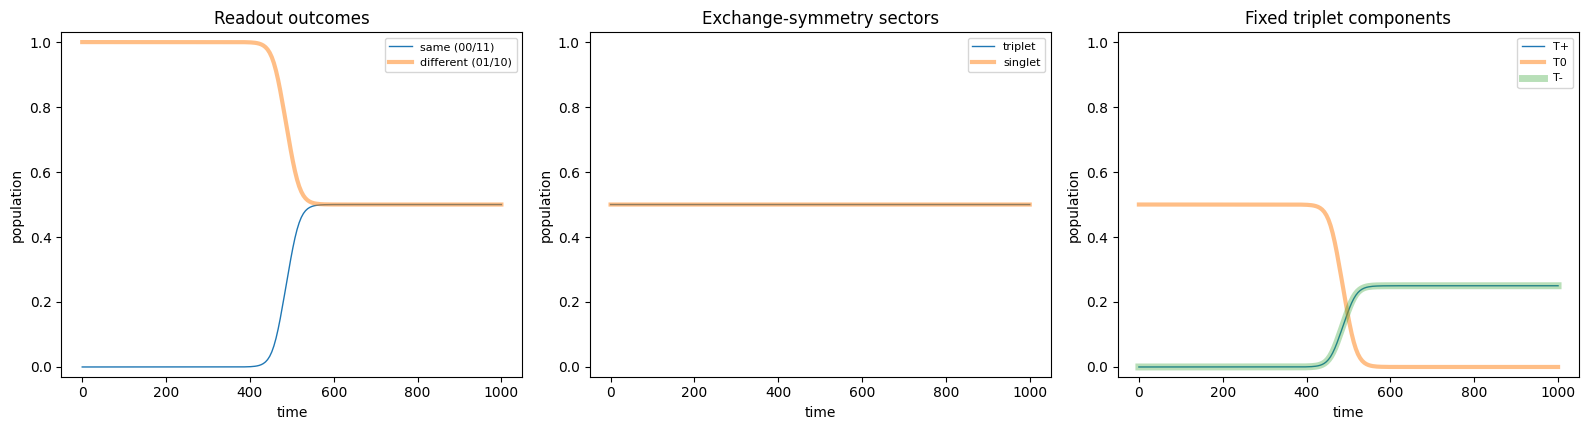

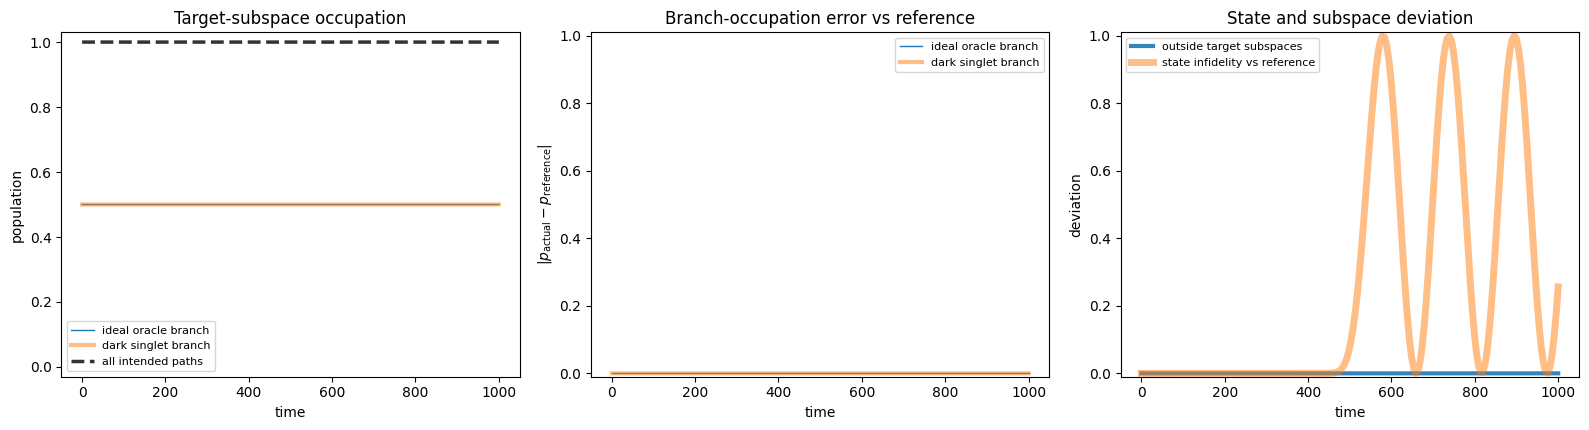

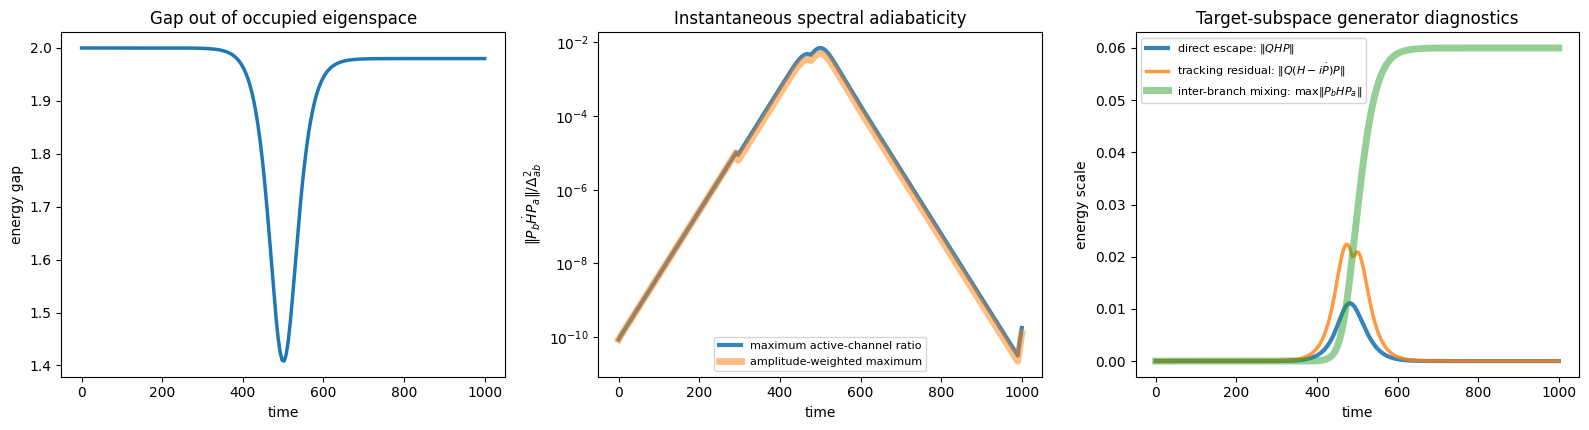

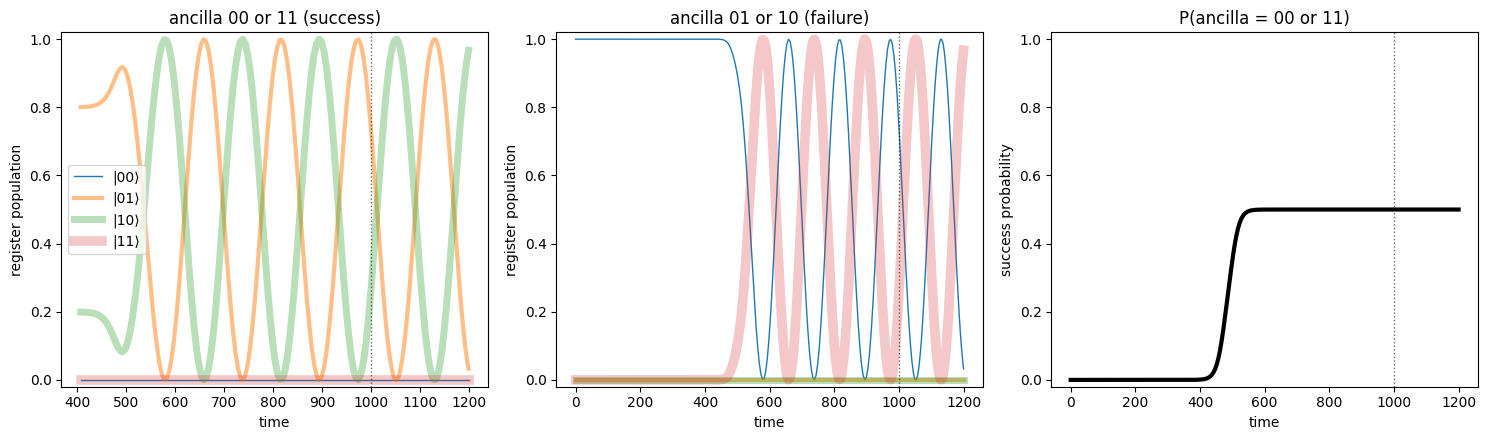

In [8]:
figures_asym_ix, metrics_asym_ix = plot_oracle_suite(
    H_asym_ix, initial_state, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_asym_ix["final_metrics"]

## Asymmetric \(I_x\) coupling - one register-ancilla pair

The ideal coupling contains the pair term \(A(t)s_iX_{r_i}X_{a_j}\). The knob \(\epsilon_{I_x}^{\mathrm{single}}\) strengthens exactly one chosen pair:
$$
\delta H_{I_x}^{(r_i,a_j)}(t)=\epsilon_{I_x}^{\mathrm{single}}A(t)X_{r_i}X_{a_j}.
$$
Choose \((r_i,a_j)\) in the knob cell below.

In [9]:
# Choose one register-ancilla pair and its fractional extra coupling.
ix_single_pair = ("r1", "a1")
epsilon_ix_single = 0.10
ix_pair_terms = {
    ("r1", "a1"): Xr1Xa1, ("r1", "a2"): Xr1Xa2,
    ("r2", "a1"): Xr2Xa1, ("r2", "a2"): Xr2Xa2,
}
H_asym_ix_single = H0 + A * (epsilon_ix_single * ix_pair_terms[ix_single_pair])

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1200, method

{'target_subspace_departure': 3.863576125695545e-14,
 'reference_state_infidelity': 0.919444705905557}

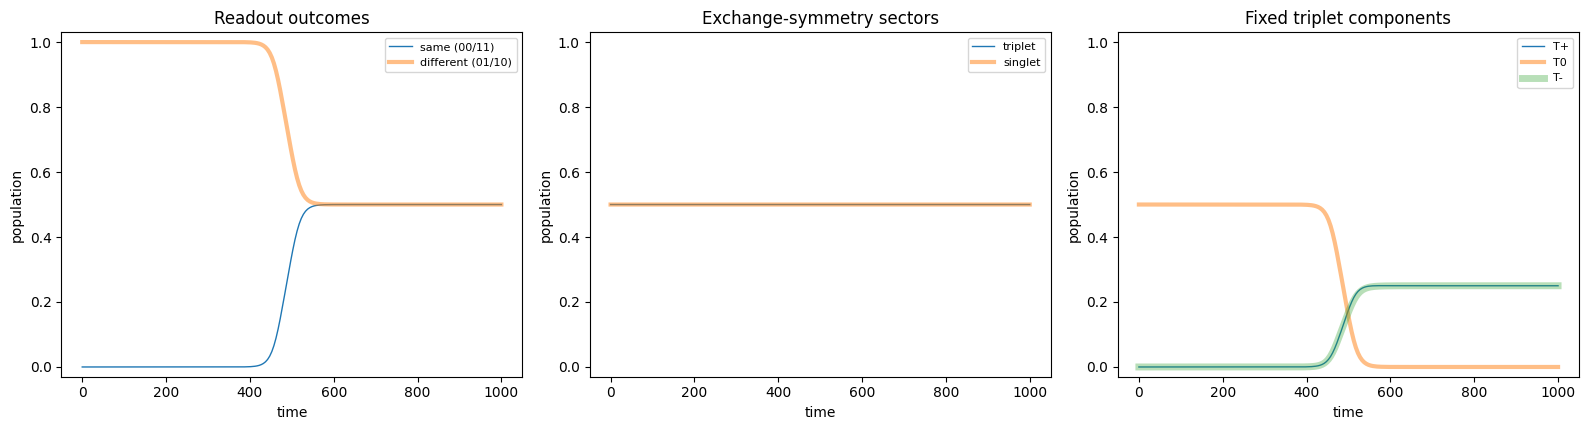

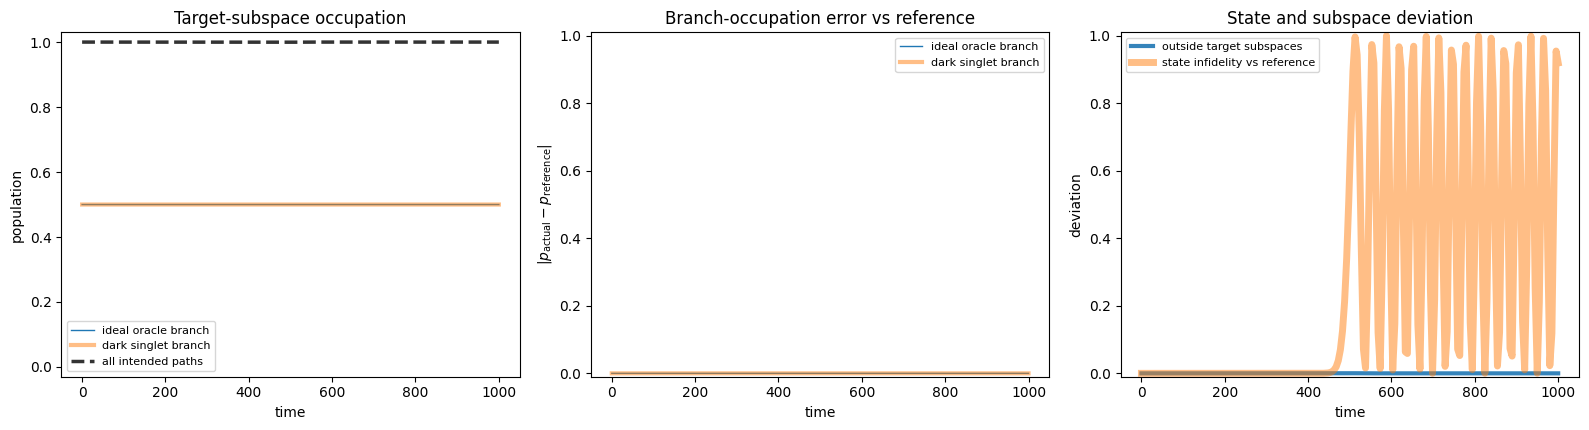

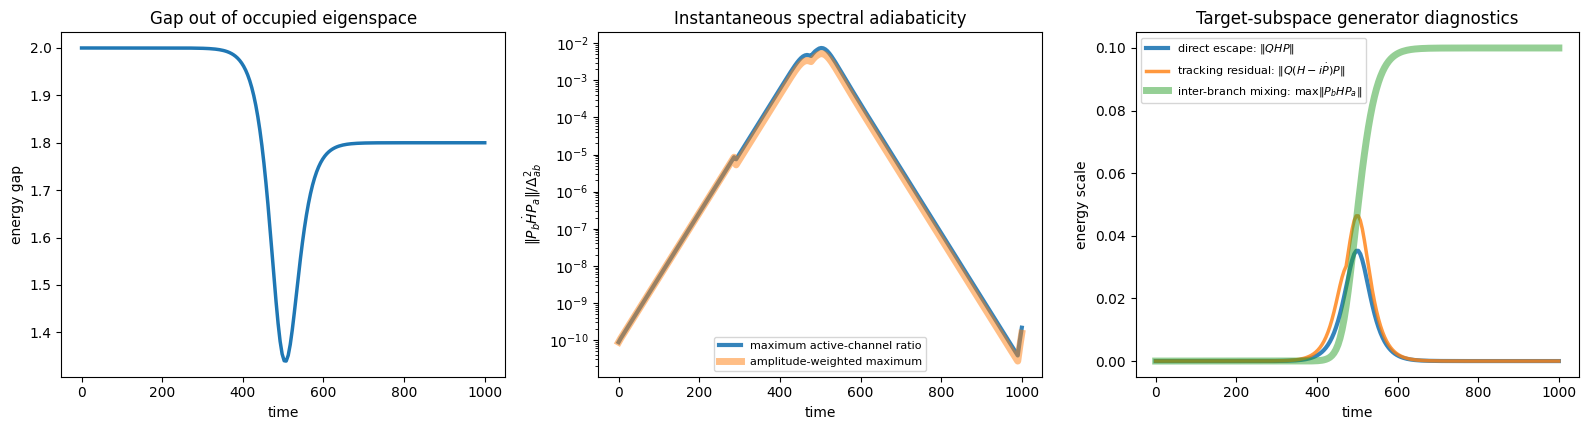

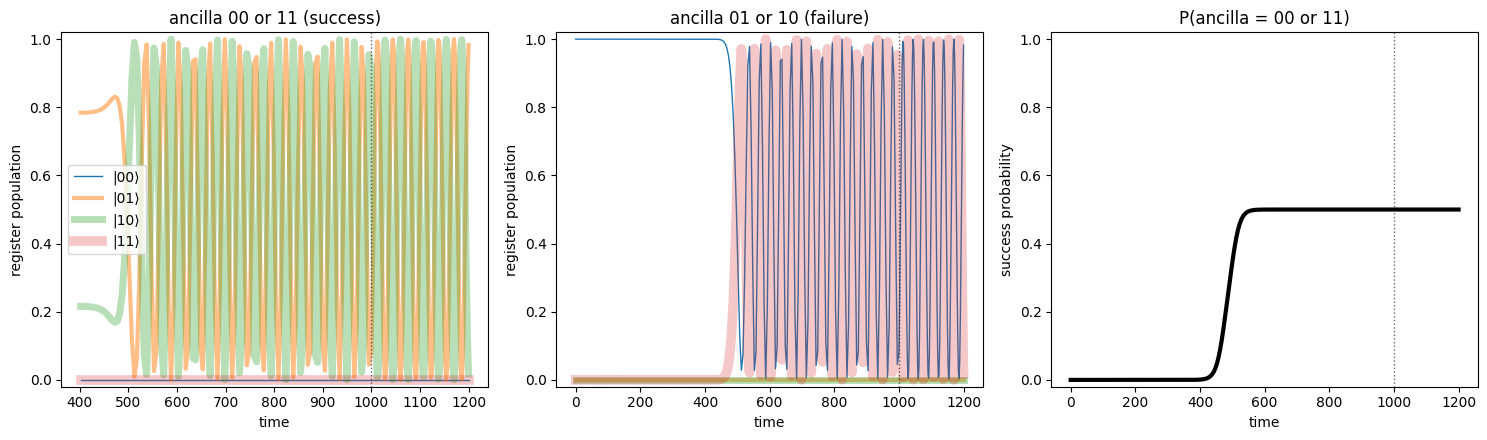

In [10]:
figures_asym_ix_single, metrics_asym_ix_single = plot_oracle_suite(
    H_asym_ix_single, initial_state, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_asym_ix_single["final_metrics"]

## Asymmetric \(I_z\) coupling to the ancillas - differential mode

The ideal ancilla \(Z\)-field is
$$
H_Z^{\mathrm{ideal}}(t)=B(t)(Z_{a_1}+Z_{a_2}).
$$

The knob \(\epsilon_{I_z}\) adds an opposite field error:
$$
\delta H_{I_z}(t)=\epsilon_{I_z}B(t)(Z_{a_1}-Z_{a_2}).
$$

In [11]:
# Single error knob: fractional differential ancilla Z-field.
epsilon_iz = 0.10
H_asym_iz = H0 + B * (epsilon_iz * (Za1 - Za2))

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(10 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(10 anonymous terms)): t=0 -> 1200, meth

{'target_subspace_departure': 7.970564652737266e-09,
 'reference_state_infidelity': 0.9420910828209966}

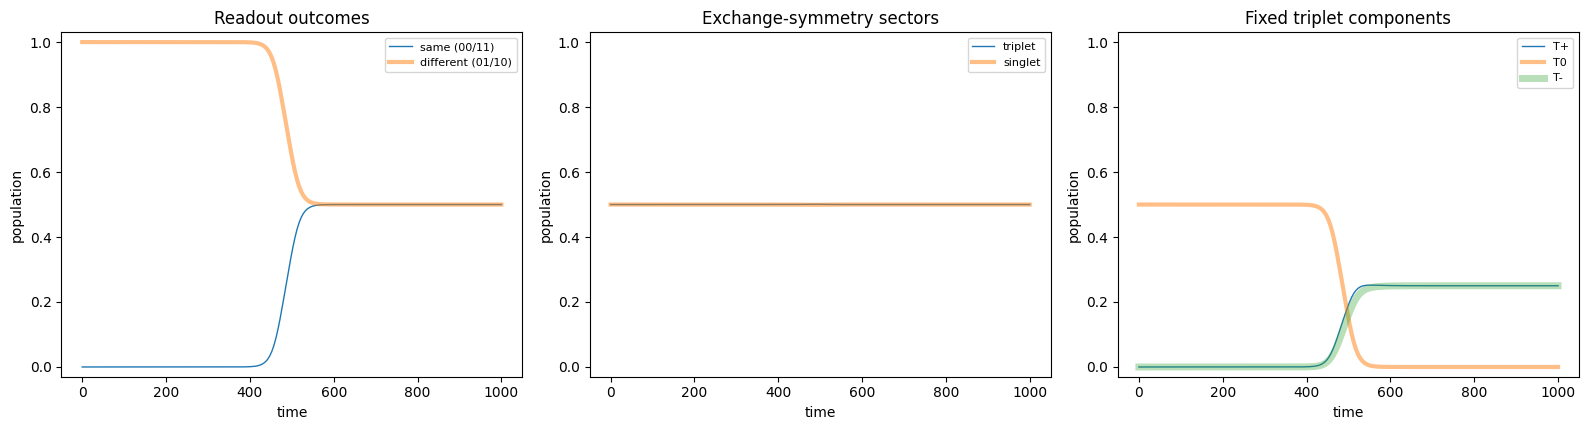

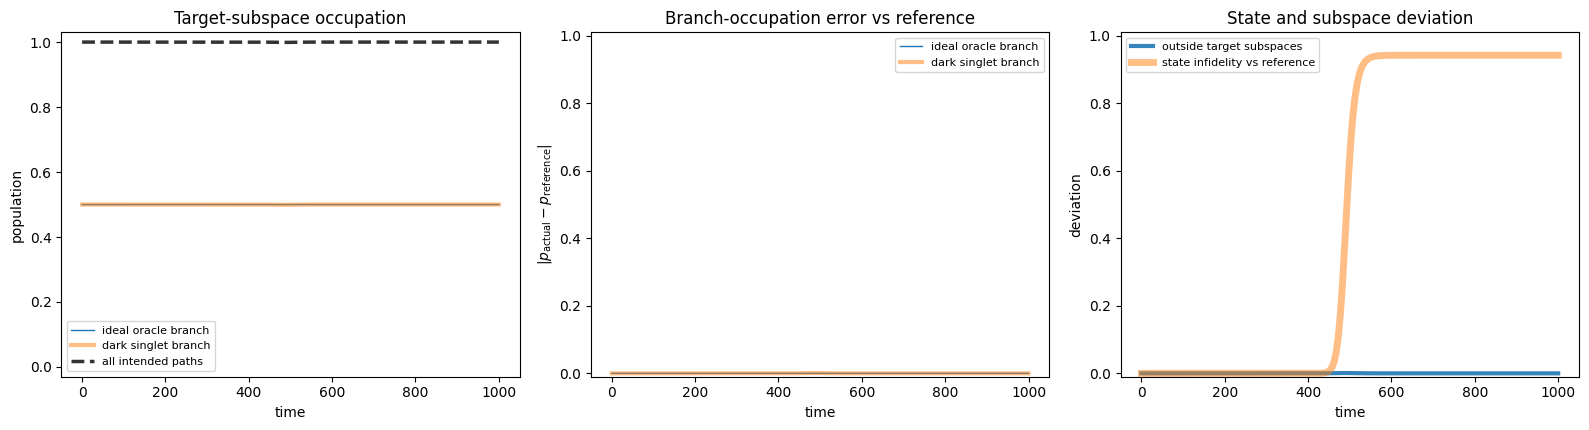

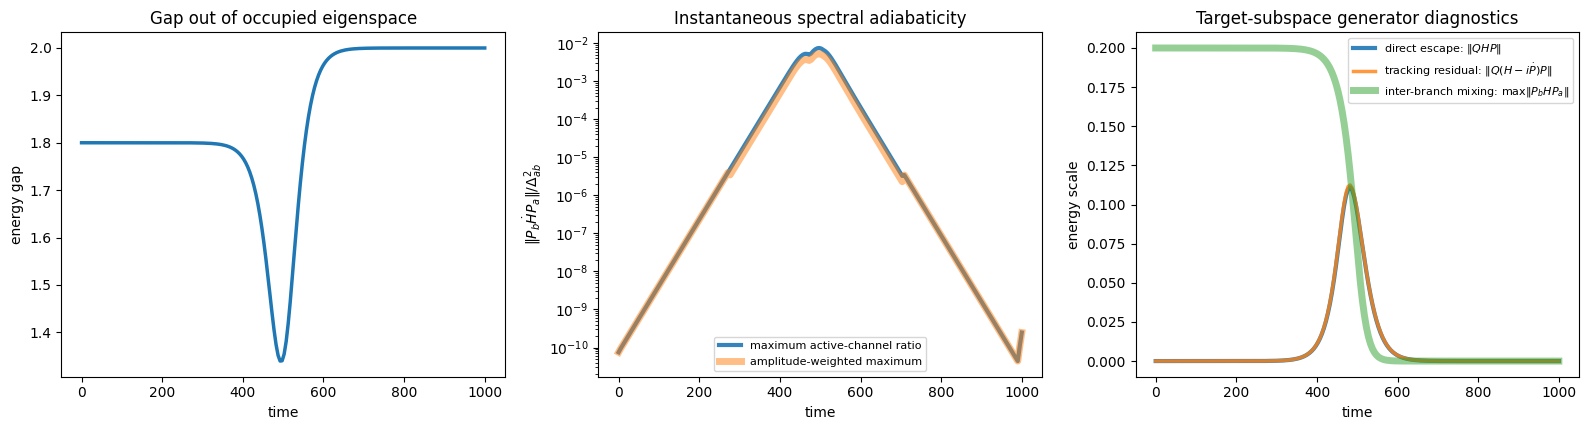

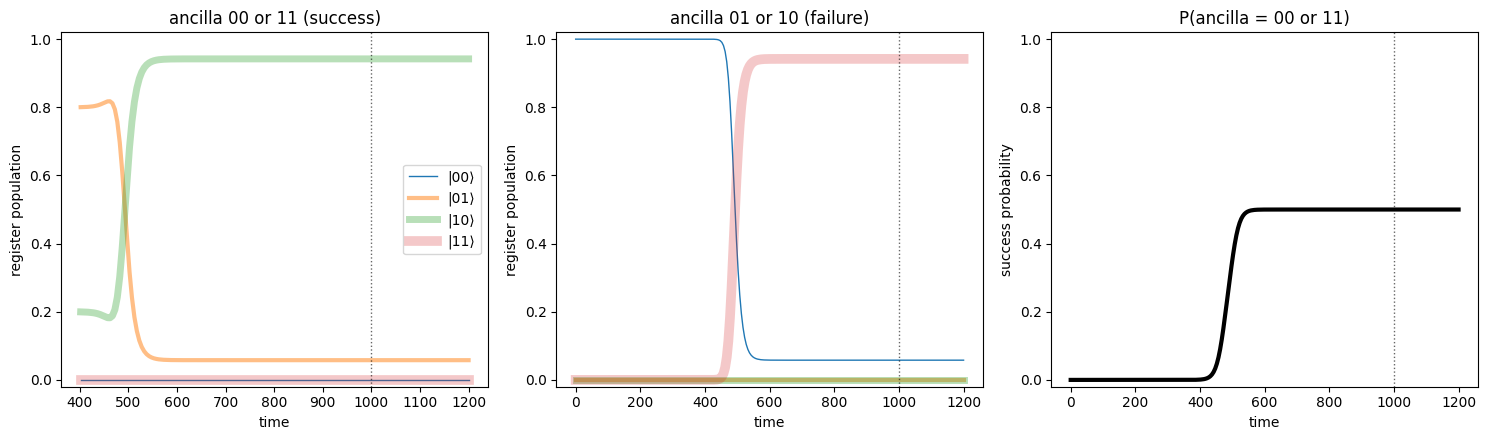

In [ ]:
figures_asym_iz, metrics_asym_iz = plot_oracle_suite(
    H_asym_iz, initial_state_gate, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_asym_iz["final_metrics"]

## Asymmetric \(I_z\) coupling - one ancilla only

The ideal ancilla field is \(B(t)(Z_{a_1}+Z_{a_2})\). The knob \(\epsilon_{I_z}^{\mathrm{single}}\) adds a field to one selected ancilla:
$$
\delta H_{I_z}^{(a_j)}(t)=\epsilon_{I_z}^{\mathrm{single}}B(t)Z_{a_j}.
$$

In [13]:
# Choose which ancilla receives the extra Z-field.
iz_single_ancilla = "a1"
epsilon_iz_single = 0.10
iz_single_terms = {"a1": Za1, "a2": Za2}
H_asym_iz_single = H0 + B * (epsilon_iz_single * iz_single_terms[iz_single_ancilla])

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1200, method

{'target_subspace_departure': 2.046474101291551e-12,
 'reference_state_infidelity': 0.7472915297726732}

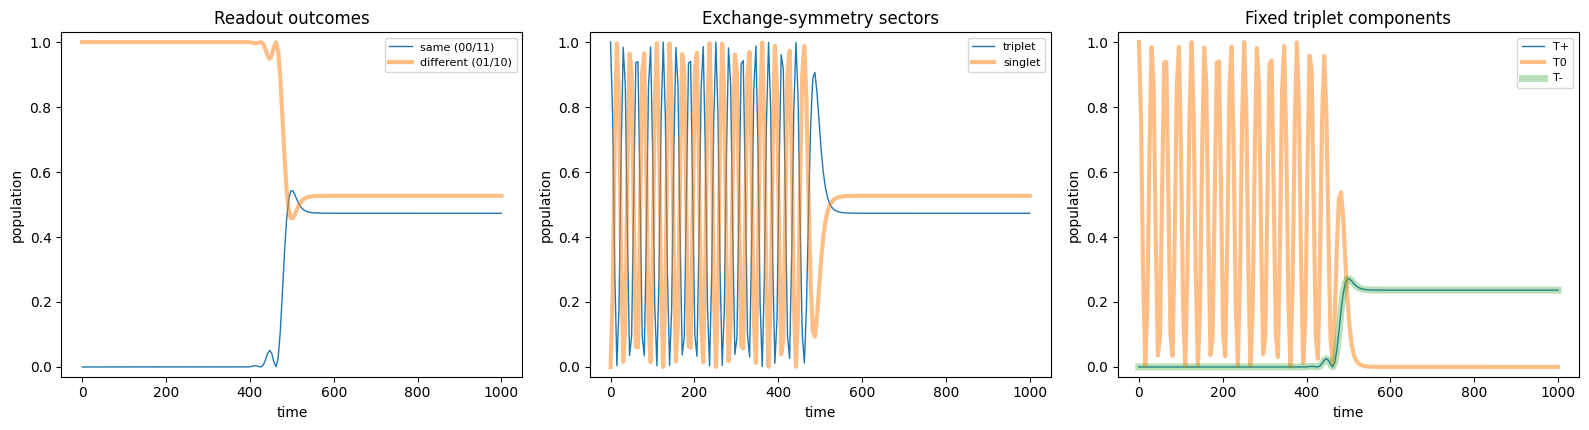

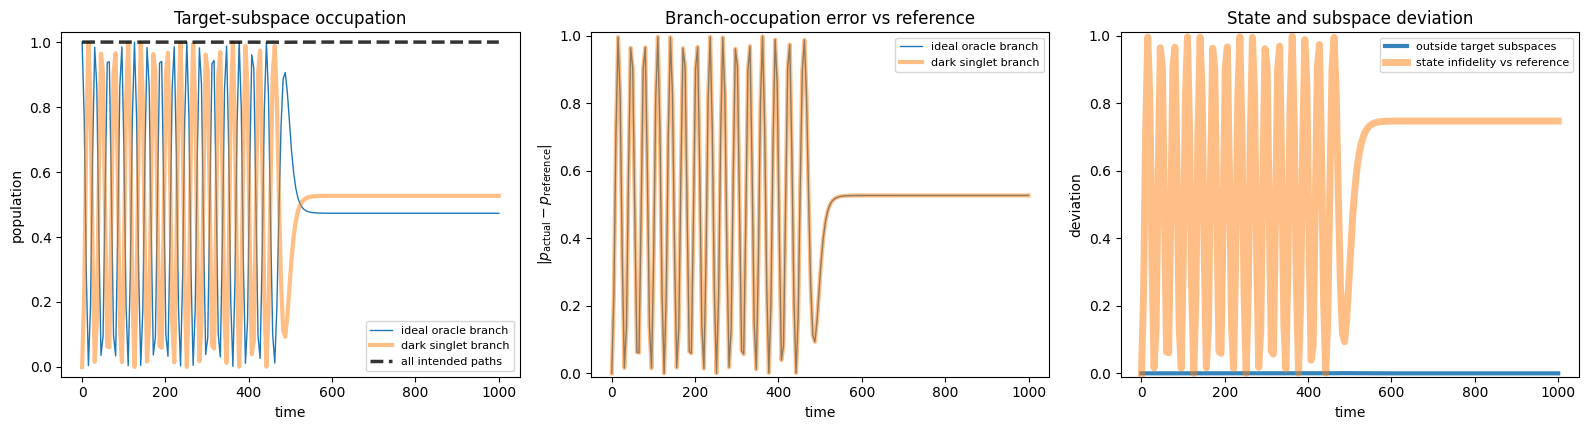

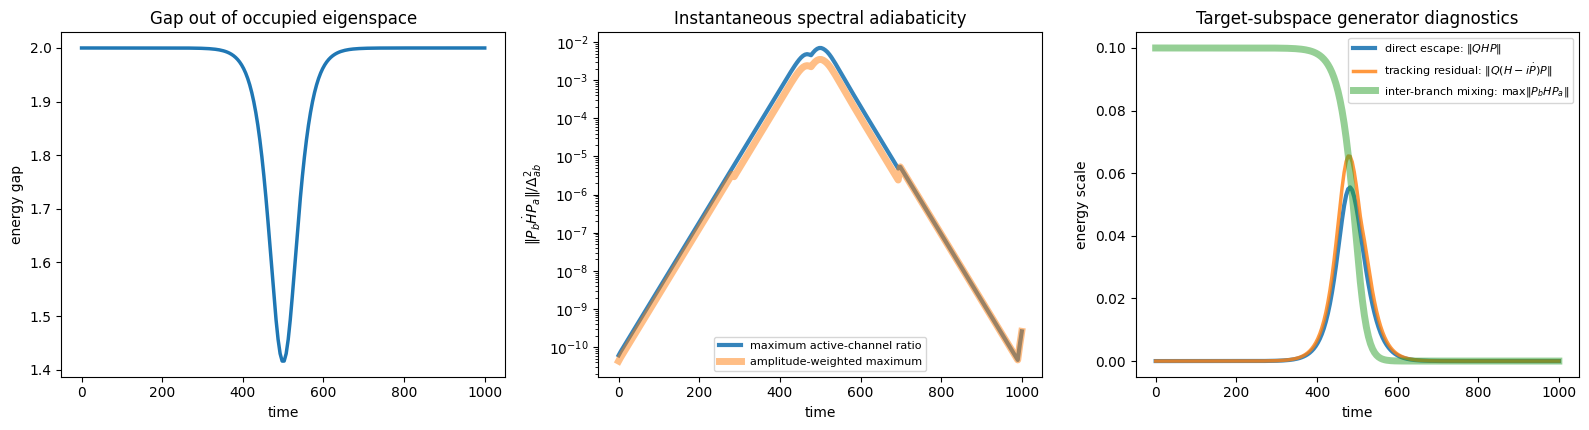

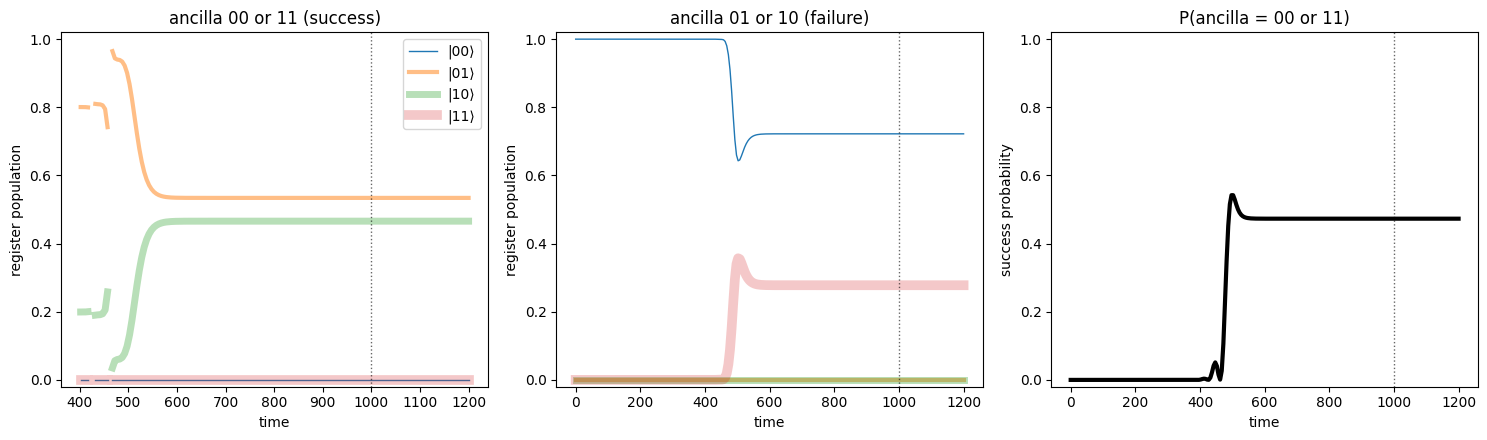

In [22]:
figures_asym_iz_single, metrics_asym_iz_single = plot_oracle_suite(
    H_asym_iz_single, initial_state_gate, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_asym_iz_single["final_metrics"]

## Incorrect register encoding

The intended register-1 coupling is
$$
H_{r_1}^{\mathrm{ideal}}(t)=A(t)s_1X_{r_1}(X_{a_1}+X_{a_2}).
$$

The knob \(\delta s_1\) changes the encoding to \(s_1+\delta s_1\), giving
$$
\delta H_{\mathrm{enc}}(t)=A(t)\delta s_1X_{r_1}(X_{a_1}+X_{a_2}).
$$

In [15]:
# Positive shift makes s1 farther from s2 here; negative makes it closer.
encoding_shift = 0.10
s1_encoded = s1 + encoding_shift
H_bad_encoding = H0 + A * (encoding_shift * (Xr1Xa1 + Xr1Xa2))

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(10 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(10 anonymous terms)): t=0 -> 1200, meth

{'target_subspace_departure': 2.8199664825478976e-14,
 'reference_state_infidelity': 5.46229728115577e-14}

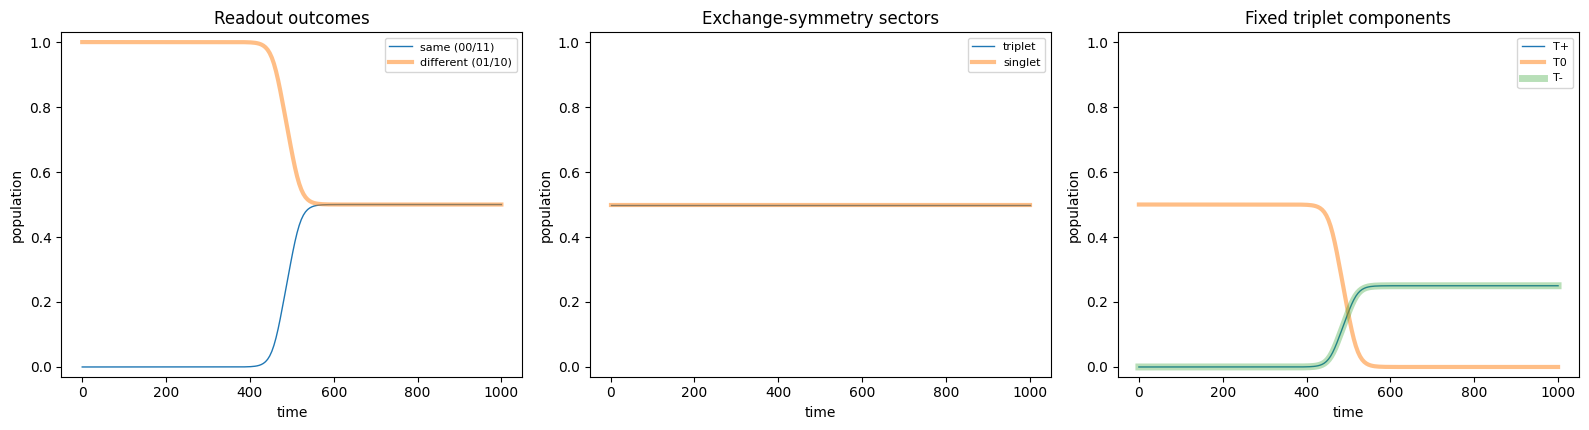

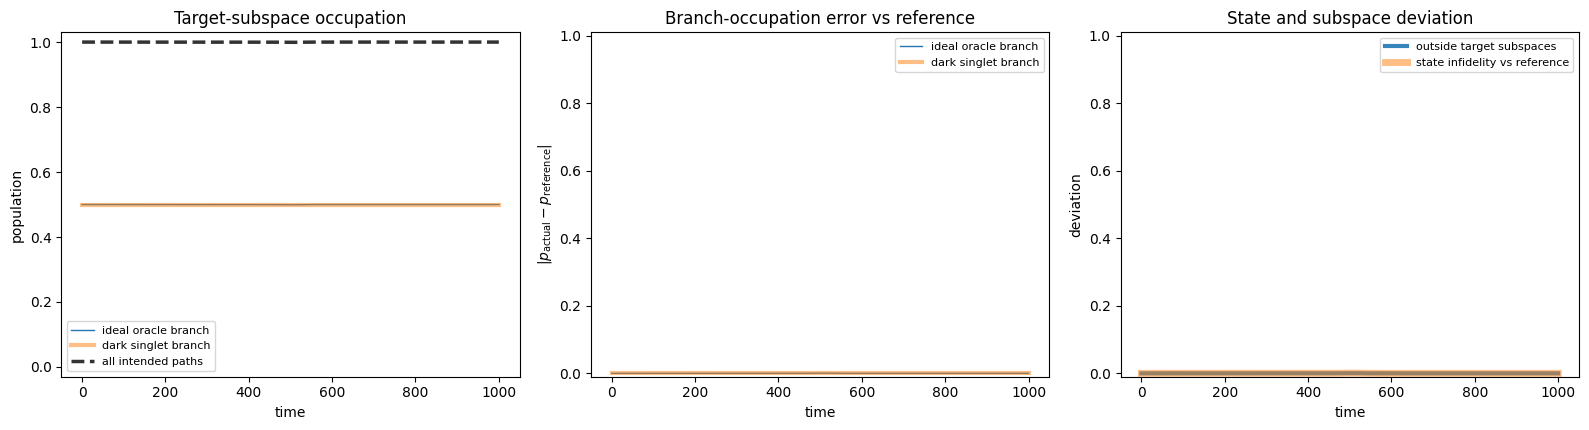

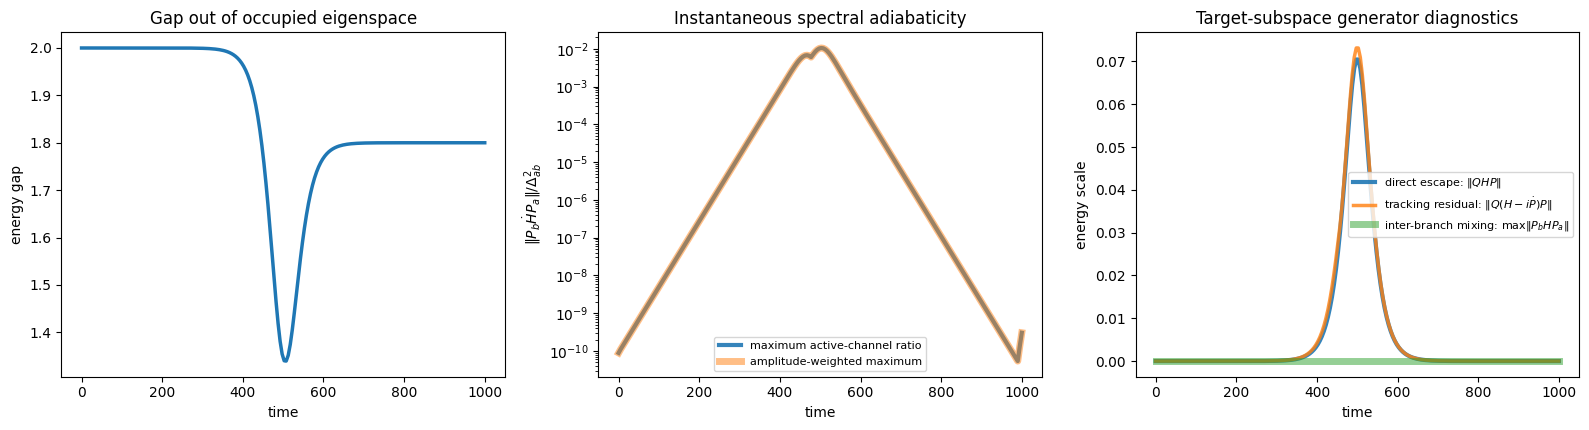

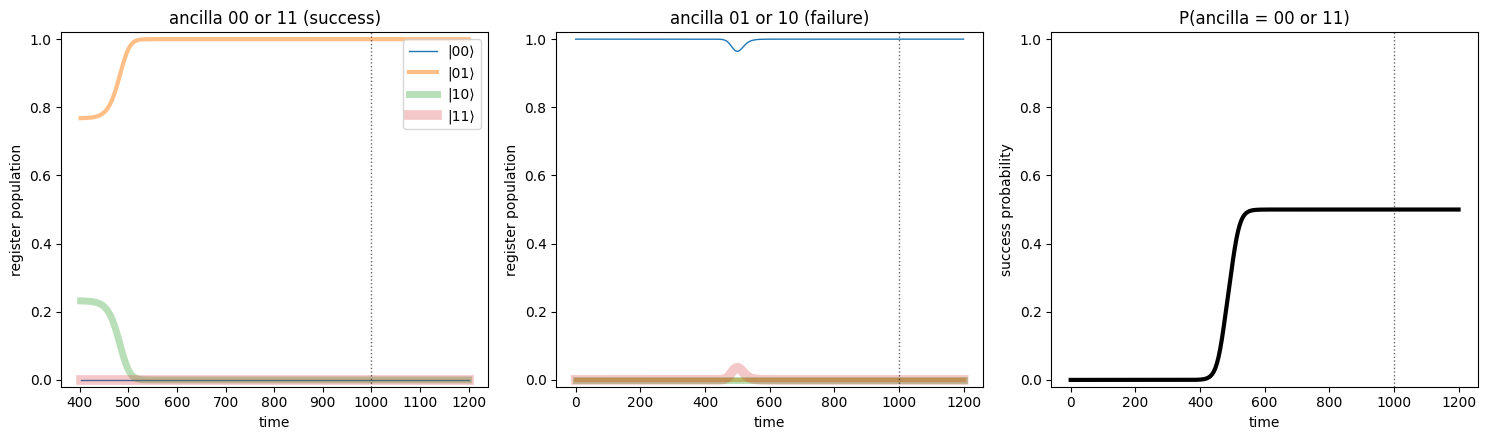

In [16]:
figures_bad_encoding, metrics_bad_encoding = plot_oracle_suite(
    H_bad_encoding, initial_state, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_bad_encoding["final_metrics"]

## Register-register coupling

The ideal Hamiltonian has no direct registerâ€“register term. The knob \(\epsilon_{rr}\) adds
$$
\delta H_{rr}(t)=A(t)\epsilon_{rr}X_{r_1}X_{r_2}.
$$

In [17]:
# Single error knob: direct register-register coupling strength.
epsilon_rr = 0.10
H_register_register = H0 + A * (epsilon_rr * Xr1Xr2)

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1200, method

{'target_subspace_departure': 2.653433028854124e-14,
 'reference_state_infidelity': 0.06884056385457193}

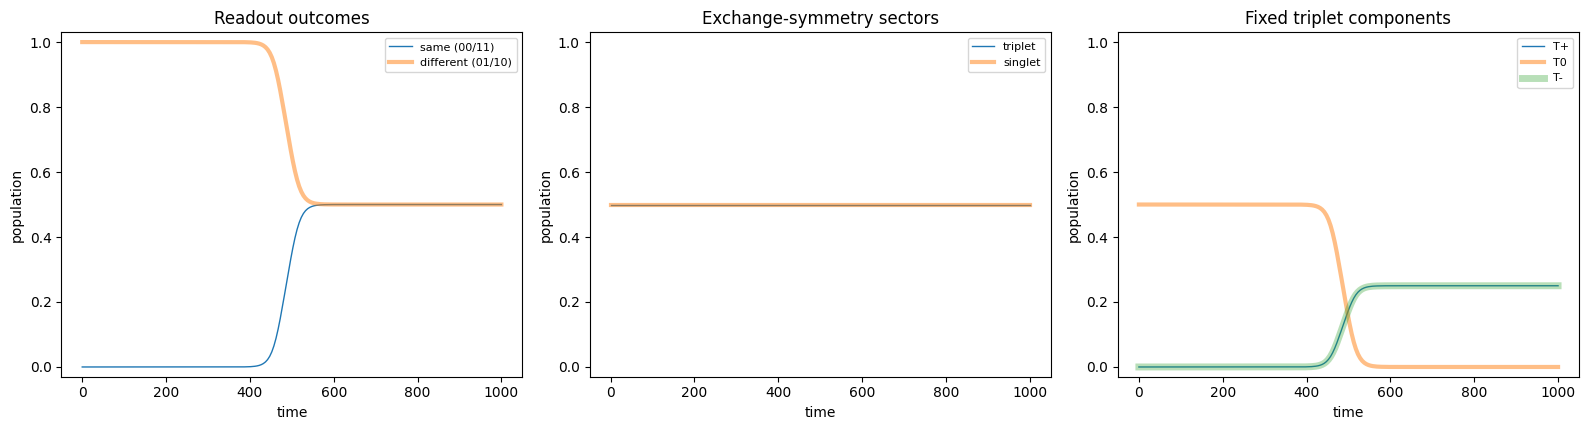

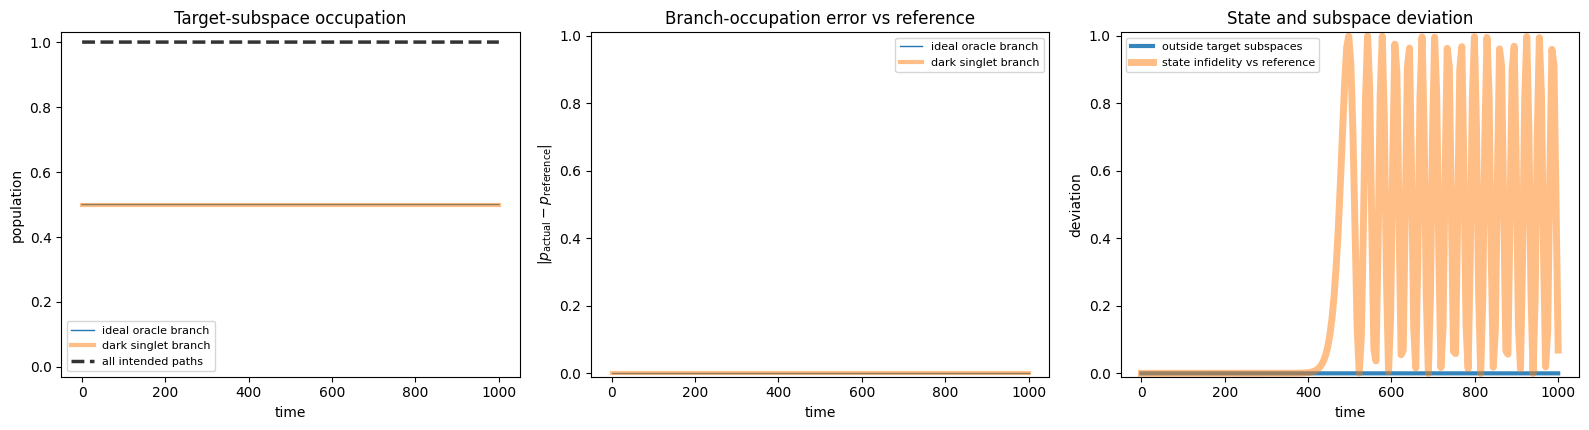

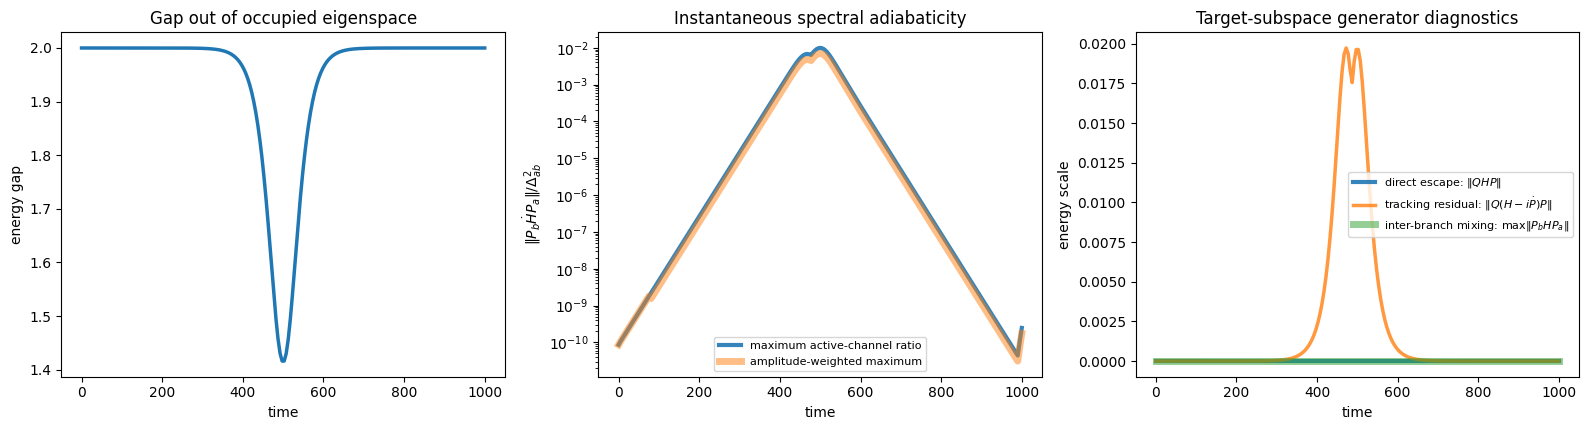

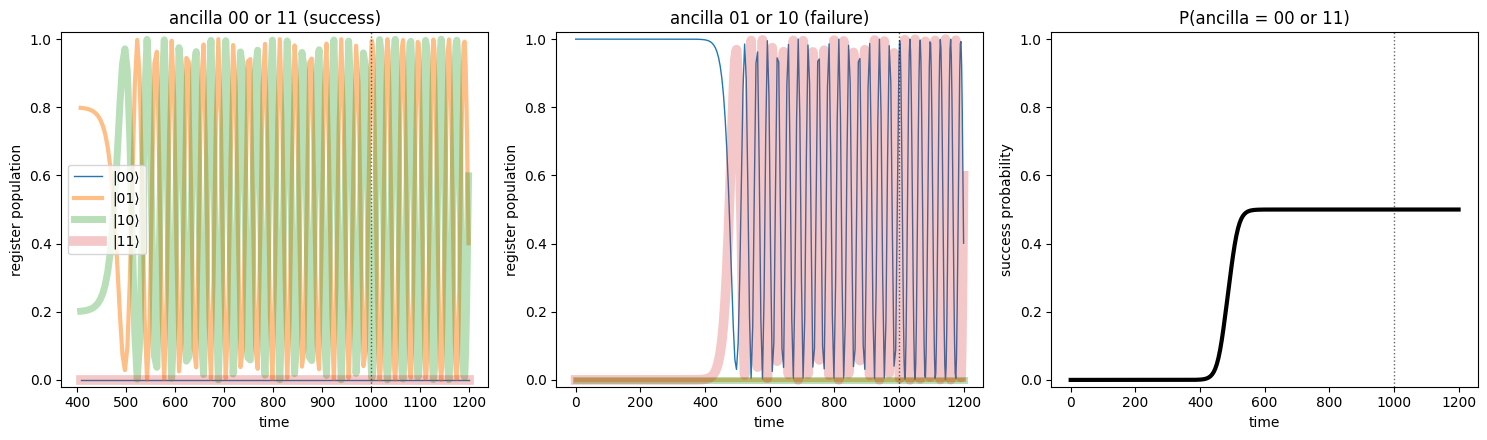

In [18]:
figures_rr, metrics_rr = plot_oracle_suite(
    H_register_register, initial_state, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_rr["final_metrics"]

## Ancilla-ancilla coupling

$$
\delta H_{aa}(t)=A(t)\epsilon_{aa}X_{a_1}X_{a_2}.
$$

(<Figure size 1700x480 with 3 Axes>,
 array([<Axes: title={'center': 'Full instantaneous spectrum'}, xlabel='time', ylabel='energy'>,
        <Axes: title={'center': 'Minimum distinct-level gap'}, xlabel='time', ylabel='smallest nonzero spacing'>,
        <Axes: title={'center': 'Register-X sectors'}, xlabel='time', ylabel='energy'>],
       dtype=object))

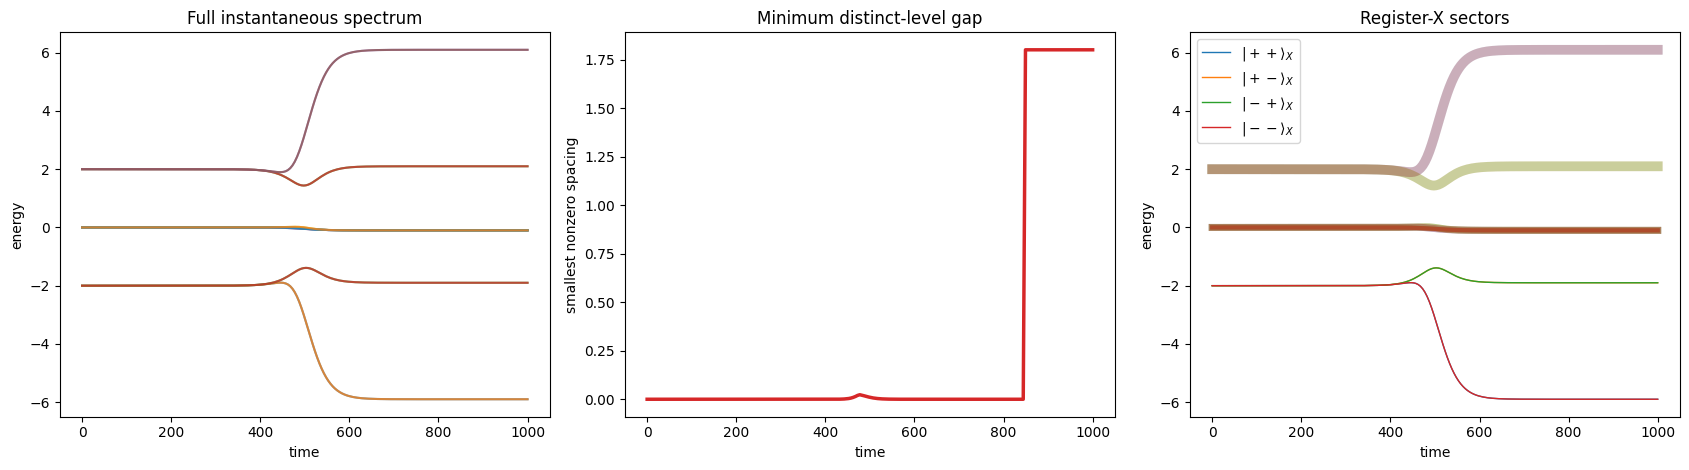

In [19]:
# Single error knob: direct ancilla-ancilla coupling strength.
epsilon_aa = 0.1
H_ancilla_ancilla = H0 + A * (epsilon_aa * Xa1Xa2)

# ancilla_ancilla = pauli_term("Xa1 Ya2") + pauli_term("Ya1 Xa2") + pauli_term("Ya1 Ya2") + Xa1Xa2   
# H_ancilla_ancilla = H0 + B * (epsilon_aa * (Xa1Xa2 + pauli_term("Ya1 Ya2"))) + A * (epsilon_aa * (Xa1Xa2 + pauli_term("Ya1 Ya2")))
# H_ancilla_ancilla = H0 + A * (epsilon_aa * ancilla_ancilla)
plot_energy_characterization(H_ancilla_ancilla, times)

[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(8 anonymous terms)): t=0 -> 1000, method=dop853, rtol=1e-08, atol=1e-10
[HamiltonianEvolution] note: System has unpicklable parameters (e.g. lambda coefficients), so the stale-physics guard is unavailable -- do not mutate it while this evolution is alive.
[HamiltonianEvolution] QuTiP integrating System(subsystems=(r1:2, r2:2, a1:2, a2:2), H=(9 anonymous terms)): t=0 -> 1200, method

{'target_subspace_departure': 2.3647750424515834e-14,
 'reference_state_infidelity': 0.9251624172537862}

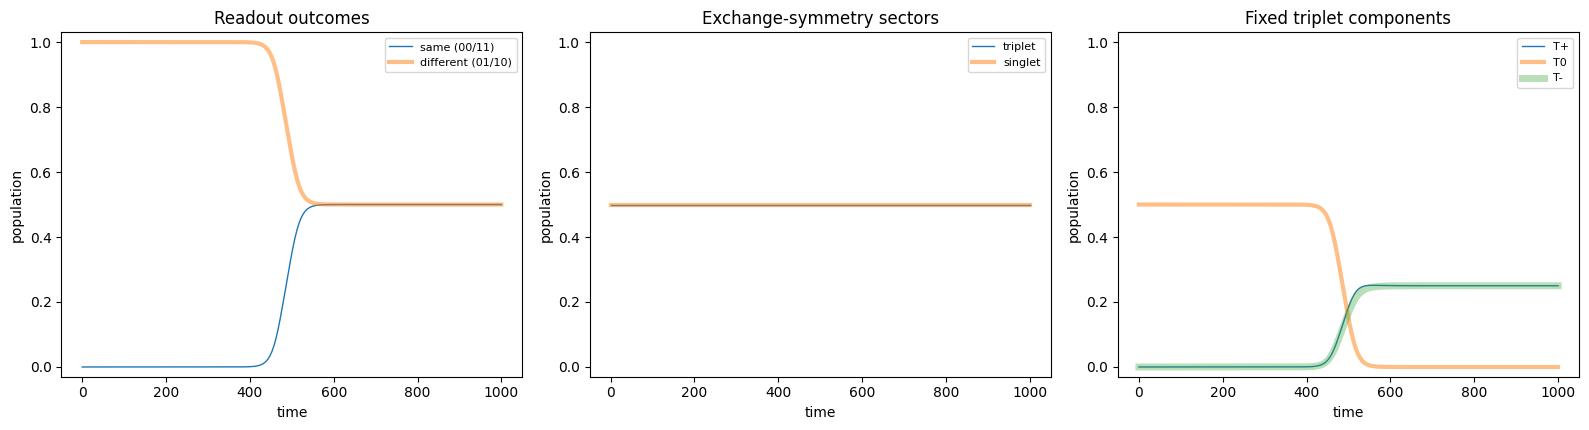

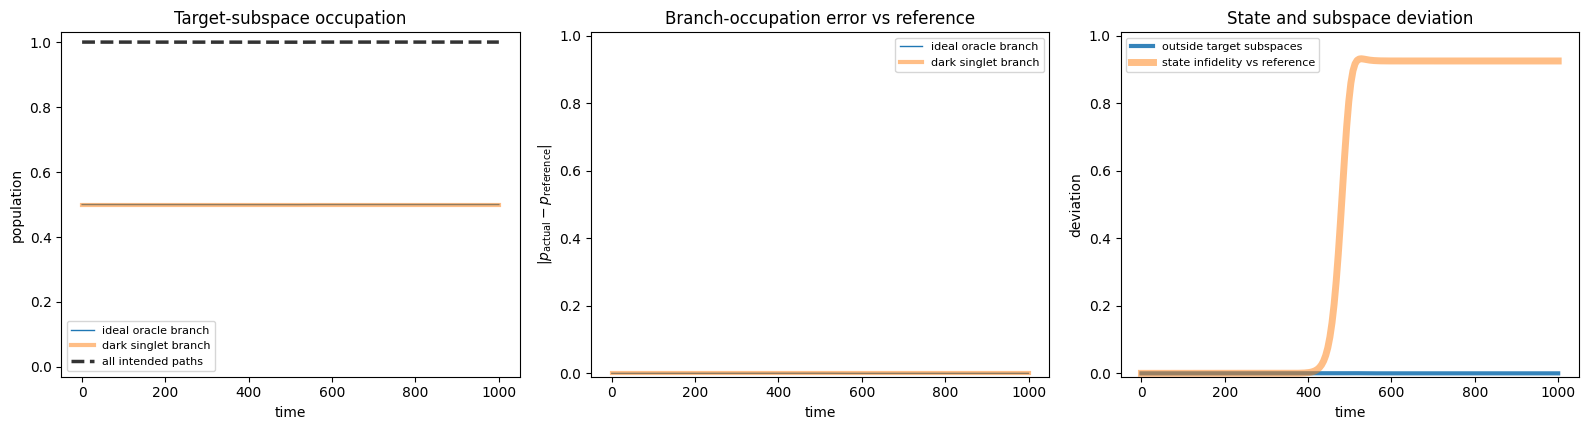

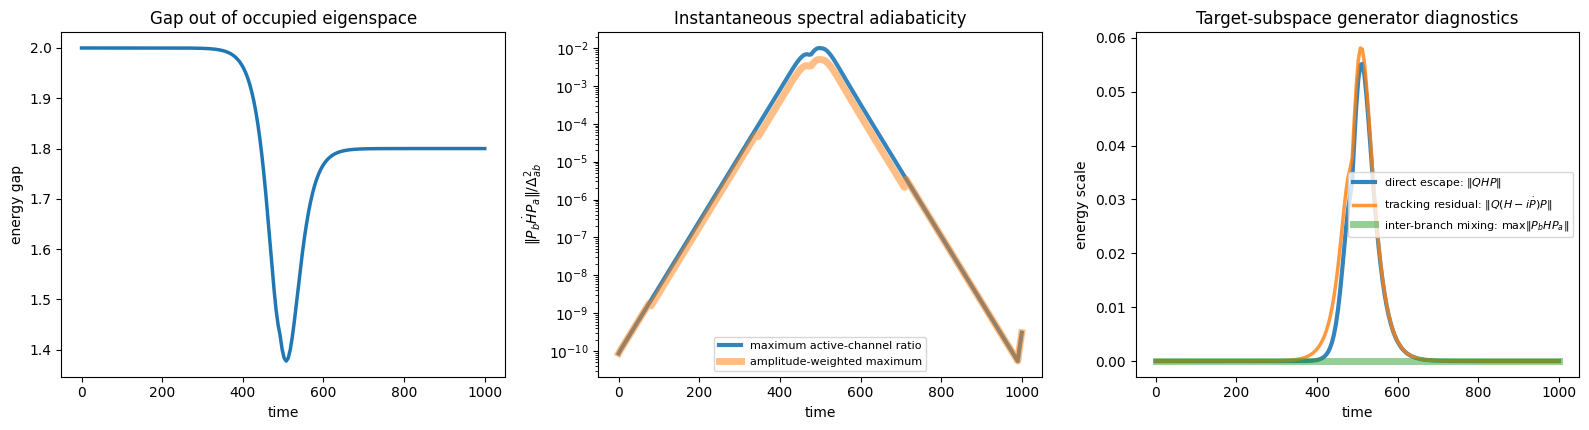

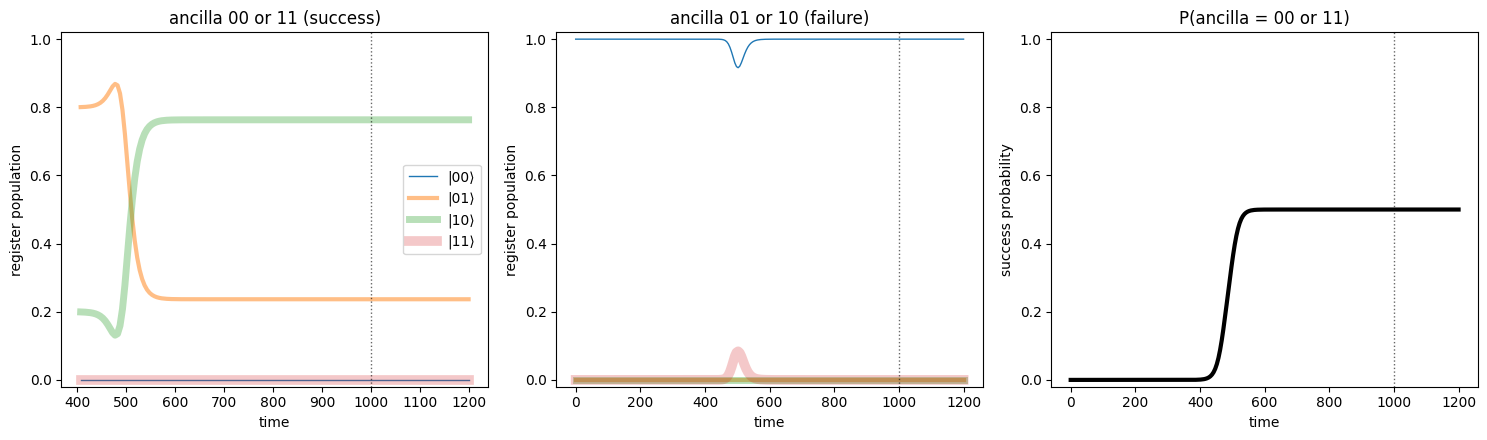

In [21]:
figures_aa, metrics_aa = plot_oracle_suite(
    H_ancilla_ancilla, initial_state, times, reference_system=H0,
    target_projectors={"ideal oracle branch": transported_success_projector, "dark singlet branch": P_singlet},
    diagnostic_projectors=diagnostics, diagnostic_groups=diagnostic_groups, post_time=post_time,
)
metrics_aa["final_metrics"]